In [1]:
pip install langgraph langsmith

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install langchain langchain_groq langchain_community

  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 19.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 16.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 24.3 MB/s  0:00:00

   -- -------------------------------------  1/16 [multidict]
   ----- ----------------------------------  2/16 [httpx-sse]
   ------- --------------------------------  3/16 [greenlet]
   ------- --------------------------------  3/16 [greenlet]
   ------- --------------------------------  3/16 [greenlet]
   ------- --------------------------------  3/16 [greenlet]
   ------- --------------------------------  3/16 [greenlet]
   ------- --------------------------------  3/16 [greenlet]
   ------


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
groq_api_key=''
langsmith=''

In [4]:
import os
os.environ["LANGSMITH_TRACING_V2"]="true"


In [6]:
from langchain_groq import ChatGroq

In [28]:
llm=ChatGroq(groq_api_key=groq_api_key,model_name="openai/gpt-oss-20b")

In [16]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002146922C8D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002146955FB90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
from typing import Annotated #Annotated lets you attach extra information/behavior to a type.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages #add_messages is a LangGraph state reducer designed for message histories.

In [ ]:
class State(TypedDict):
    #messages have the type "list". The 'add_messages' function
    #in the annotation defines how this state key should be updated
    #(in this case, it appends the messages to teh list,rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [19]:
graph_builder

In [20]:
def chatbot(state:State):
    return {"messages":llm.invoke(state['messages'])}


In [21]:
graph_builder.add_node("chatbot",chatbot)

In [22]:
graph_builder

In [23]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [24]:
graph=graph_builder.compile()

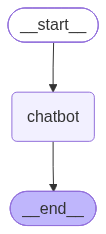

In [25]:
graph

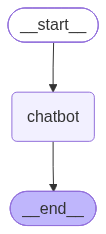

In [26]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
while True:
    user_input=input("User: ")
    if user_input.lower() in ["quit","q"]:
        print("Bye")
        break
    for event in graph.stream({'messages':("user",user_input)}):  #graph.stream() can give you events from those nodes as they execute.
        print(event.values())
        for value in event.values():
            print(value['messages'])
            print("Assistant:",value["messages"].content)

    

dict_values([{'messages': AIMessage(content='**MCP** can refer to several different things depending on the context. Here are the most common meanings:\n\n| Field | Full Form | What it is |\n|-------|-----------|------------|\n| **Electronics / Microcontrollers** | **Microchip (MCP)** | A family of microcontrollers, analog ICs, and other components made by Microchip Technology. The “MCP” prefix is used in part numbers (e.g., MCP3008, MCP2515). |\n| **Computer Science / Operating Systems** | **Master Control Program** | The central software component that manages hardware resources in some operating systems or embedded platforms. |\n| **Certifications** | **Microsoft Certified Professional** | A certification program (now largely replaced by Microsoft Certified: Azure, Microsoft 365, etc.) that demonstrates proficiency in Microsoft technologies. |\n| **Networking** | **Multicast Control Protocol (MCP)** | A protocol used for managing multicast traffic in certain network environments. |\